#Leer el dataset en formato excel

In [71]:
import pandas as pd

df_raw = pd.read_excel("Afluencia_Metro_2024.xlsx", header=1, dtype=str)

#Configurar las caracteristicas iniciales de nuestro dataset

In [72]:
# Renombrar las dos primeras columnas fijas
df_raw = df_raw.rename(columns={
    df_raw.columns[0]: "fecha",
    df_raw.columns[1]: "linea"
})

print(df_raw.columns.tolist())

['fecha', 'linea', datetime.time(4, 0), datetime.time(5, 0), datetime.time(6, 0), datetime.time(7, 0), datetime.time(8, 0), datetime.time(9, 0), datetime.time(10, 0), datetime.time(11, 0), datetime.time(12, 0), datetime.time(13, 0), datetime.time(14, 0), datetime.time(15, 0), datetime.time(16, 0), datetime.time(17, 0), datetime.time(18, 0), datetime.time(19, 0), datetime.time(20, 0), datetime.time(21, 0), datetime.time(22, 0), datetime.time(23, 0), 'Total general (Número de pasajeros)']


In [73]:
#Eliminamos la columna total de pasajeros por día porqué no es relevante a nuestro problema
df_raw = df_raw.drop(columns=["Total general (Número de pasajeros)"], errors='ignore')

In [74]:
#Limpiar la columna fecha
df_raw["fecha"] = pd.to_datetime(
    df_raw["fecha"],
    format="%d.%m.%Y",
    errors="coerce"
)

# Eliminar filas completamente vacías que Excel a veces inserta
df_raw = df_raw.dropna(subset=["fecha", "linea"])

In [75]:
df_raw

,fecha,linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,14:00:00,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00
0,2024-01-01,LÍNEA 1,180,858,886,721,659,820,952,1083,...,1418,1563,1734,2108,2352,1903,1676,1132,139,NaN
1,2024-01-01,LÍNEA 2,1,149,143,74,100,135,116,225,...,198,188,277,291,284,212,152,100,9,NaN
2,2024-01-01,LÍNEA A,1460,5488,5769,4752,3993,4512,5551,7197,...,10362,10666,12998,15376,16932,14537,11750,7729,664,NaN
3,2024-01-01,LÍNEA B,231,718,826,672,641,818,1060,1398,...,1741,1956,2228,2587,2749,2043,1302,893,85,NaN
4,2024-01-01,LÍNEA H,NaN,NaN,NaN,NaN,NaN,50,62,71,...,76,72,93,83,113,80,39,25,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4289,2024-12-31,LÍNEA L,NaN,NaN,NaN,NaN,1,114,154,322,...,337,268,122,76,NaN,NaN,NaN,NaN,NaN,NaN
4290,2024-12-31,LÍNEA M,138,306,390,404,308,305,322,344,...,507,559,550,540,668,518,473,313,79,NaN
4291,2024-12-31,LÍNEA O,189,483,516,483,424,377,301,331,...,459,406,457,535,522,403,233,115,20,NaN
4292,2024-12-31,LÍNEA P,447,885,1035,1097,872,753,791,853,...,656,583,711,632,599,657,613,461,8,NaN


In [76]:
# Renombrar columnas de hora: datetime.time(4, 0) → 4
import datetime

df_raw.columns = [
    col.hour if isinstance(col, datetime.time) else col
    for col in df_raw.columns
]

print(df_raw.columns.tolist())

['fecha', 'linea', 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [77]:
df_raw.head()

,fecha,linea,4,5,6,7,8,9,10,11,...,14,15,16,17,18,19,20,21,22,23
0,2024-01-01,LÍNEA 1,180,858,886,721,659,820,952,1083,...,1418,1563,1734,2108,2352,1903,1676,1132,139,NaN
1,2024-01-01,LÍNEA 2,1,149,143,74,100,135,116,225,...,198,188,277,291,284,212,152,100,9,NaN
2,2024-01-01,LÍNEA A,1460,5488,5769,4752,3993,4512,5551,7197,...,10362,10666,12998,15376,16932,14537,11750,7729,664,NaN
3,2024-01-01,LÍNEA B,231,718,826,672,641,818,1060,1398,...,1741,1956,2228,2587,2749,2043,1302,893,85,NaN
4,2024-01-01,LÍNEA H,NaN,NaN,NaN,NaN,NaN,50,62,71,...,76,72,93,83,113,80,39,25,4,NaN


#Número de muestras y variables actuales (4294, 22)

In [78]:
df_raw.shape

(4294, 22)

# Identificación de datos por columna

In [79]:
df_raw.isnull().sum()

fecha       0
linea       0
4         661
5         656
6         657
7         650
8         273
9           4
10          6
11          8
12          5
13          6
14          6
15          7
16          8
17          3
18        264
19        325
20        324
21        324
22        348
23       1603
dtype: int64

# Transformación de nuestro dataset
1. Identificamos que para nuestro problema es importante tener unas columnas especificas como el día de la semana y mes del registro, ya que la afluencia en la red puede variar con esto. El año no lo implementaremos ya que es el mismo para todos y no nos entrega información.

In [80]:
# Extraer variables temporales desde la columna fecha
df_raw["semana"] = df_raw["fecha"].dt.isocalendar().week.astype(int)
df_raw["dia_semana"] = df_raw["fecha"].dt.dayofweek  # 0=lunes, 6=domingo

# Verificación
print(f"\nSemanas únicas: {sorted(df_raw['semana'].unique())}")
print(f"Días únicos:    {sorted(df_raw['dia_semana'].unique())}")


Semanas únicas: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
Días únicos:    [0, 1, 2, 3, 4, 5, 6]


In [81]:
df_raw

,fecha,linea,4,5,6,7,8,9,10,11,...,16,17,18,19,20,21,22,23,semana,dia_semana
0,2024-01-01,LÍNEA 1,180,858,886,721,659,820,952,1083,...,1734,2108,2352,1903,1676,1132,139,NaN,1,0
1,2024-01-01,LÍNEA 2,1,149,143,74,100,135,116,225,...,277,291,284,212,152,100,9,NaN,1,0
2,2024-01-01,LÍNEA A,1460,5488,5769,4752,3993,4512,5551,7197,...,12998,15376,16932,14537,11750,7729,664,NaN,1,0
3,2024-01-01,LÍNEA B,231,718,826,672,641,818,1060,1398,...,2228,2587,2749,2043,1302,893,85,NaN,1,0
4,2024-01-01,LÍNEA H,NaN,NaN,NaN,NaN,NaN,50,62,71,...,93,83,113,80,39,25,4,NaN,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4289,2024-12-31,LÍNEA L,NaN,NaN,NaN,NaN,1,114,154,322,...,122,76,NaN,NaN,NaN,NaN,NaN,NaN,1,1
4290,2024-12-31,LÍNEA M,138,306,390,404,308,305,322,344,...,550,540,668,518,473,313,79,NaN,1,1
4291,2024-12-31,LÍNEA O,189,483,516,483,424,377,301,331,...,457,535,522,403,233,115,20,NaN,1,1
4292,2024-12-31,LÍNEA P,447,885,1035,1097,872,753,791,853,...,711,632,599,657,613,461,8,NaN,1,1


La codificación de nuestras fechas quedo con el siguiente formato:

dia_semana = {0:"Lunes", 1:"Martes", 2:"Miércoles", 3:"Jueves",
                4:"Viernes", 5:"Sábado", 6:"Domingo"}

semana = {1, 2, ... , 52} -> Semana del año

2. Decidimos agregar la columna "festivo", ya que es importante junto con las fechas para la afluencia del metro, además nos servirá mas adelante con el manejo de los valores nulos.

In [14]:
!pip install holidays

^C



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 11.0 MB/s eta 0:00:00


In [82]:
import holidays

# Festivos colombianos 2024
festivos_co = holidays.Colombia(years=2024)

# Crear columna festivo
df_raw["festivo"] = df_raw["fecha"].dt.date.map(
    lambda x: 1 if x in festivos_co else 0
)

# Verificación
print(f"Días festivos detectados en el dataset: {df_raw['festivo'].sum()}")
print(f"\nFechas marcadas como festivo:")

print(df_raw[df_raw["festivo"] == 1]["fecha"].drop_duplicates().sort_values())

Días festivos detectados en el dataset: 215

Fechas marcadas como festivo:
0      2024-01-01
84     2024-01-08
981    2024-03-25
1017   2024-03-28
1029   2024-03-29
1420   2024-05-01
1563   2024-05-13
1812   2024-06-03
1895   2024-06-10
2134   2024-07-01
2341   2024-07-20
2555   2024-08-07
2698   2024-08-19
3356   2024-10-14
3605   2024-11-04
3688   2024-11-11
4008   2024-12-08
4210   2024-12-25
Name: fecha, dtype: datetime64[ns]


La librería holidays nos da los festivos en Colombia al año 2024, al analizar los resultados vimos hubieron dos festivos del 2024 que no registro por lo que decidimos agregarlos de manera manual. (24 y 31 de Marzo de 2024)

In [83]:
festivos_manuales = ["2024-03-24", "2024-03-31"]

df_raw["festivo"] = df_raw.apply(
    lambda row: 1 if str(row["fecha"].date()) in festivos_manuales else row["festivo"],
    axis=1
)

# Verificación
print(df_raw[df_raw["festivo"] == 1]["fecha"].drop_duplicates().sort_values())

0      2024-01-01
84     2024-01-08
969    2024-03-24
981    2024-03-25
1017   2024-03-28
1029   2024-03-29
1053   2024-03-31
1420   2024-05-01
1563   2024-05-13
1812   2024-06-03
1895   2024-06-10
2134   2024-07-01
2341   2024-07-20
2555   2024-08-07
2698   2024-08-19
3356   2024-10-14
3605   2024-11-04
3688   2024-11-11
4008   2024-12-08
4210   2024-12-25
Name: fecha, dtype: datetime64[ns]


3. Como lo que buscamos predecir es la afluencia para una línea del metro y hora especifica, lo que decidimos hacer es formatear estas columnas de hora como una sola y crear los registros correspondientes a cada registro por línea y hora real.

In [100]:
# Identificar columnas de hora (4 al 23)
hora_cols = [c for c in df_raw.columns if isinstance(c, int)]

# Unpivot: de formato ancho a formato largo
df_long = df_raw.melt(
    id_vars=["fecha","linea", "semana", "dia_semana", "festivo"],    # columnas que se mantienen fijas
    value_vars=hora_cols,                                 # columnas que se convierten en filas
    var_name="hora",                                      # nombre de la nueva columna categórica
    value_name="pasajeros"                                # nombre de la columna de valores
)

# Verificación
print(f"Filas antes: {len(df_raw)}")
print(f"Filas después: {len(df_long)}")
print(f"\nNulos en pasajeros: {df_long['pasajeros'].isna().sum()}")

print("\nDataset actual")
df_long.head()

Filas antes: 4294
Filas después: 85880

Nulos en pasajeros: 6138

Dataset actual


,fecha,linea,semana,dia_semana,festivo,hora,pasajeros
0,2024-01-01,LÍNEA 1,1,0,1,4,180
1,2024-01-01,LÍNEA 2,1,0,1,4,1
2,2024-01-01,LÍNEA A,1,0,1,4,1460
3,2024-01-01,LÍNEA B,1,0,1,4,231
4,2024-01-01,LÍNEA H,1,0,1,4,NaN


Con esta modificación ahora nuestro dataset cuenta con 85880 registros y 6 columnas.

Y que tenemos en total 6138 registros nulos

4. Al analizar el funcionamiento en horarios del sistema metro, identificamos que cada línea tiene horarios diferentes para cada día, por lo tanto, los valores nulos de cada línea por fuera de su horario de funcionamiento decidimos eliminarlos, ya que no son registros validos debido a que la línea no estaba operando.

Horarios lineas A - B - TA - H - J - K - M - O - P - 1 - 2

Lunes - Sabado: 4:30am - 11:00pm

Horarios lineas A - B - TA - O - 1 - 2

Domingos - Festivos: 5:00 am - 10pm

Horarios lineas K - H - J - M - P

Domingos - Festivos: 9:00 am - 10pm

Horarios linea L - 9:00am - 6:00pm (Fijo a esa fecha)


In [101]:
# Tabla de horarios operativos por línea y tipo de día
# tipo_dia: 0 = lunes-sabado, 1 = domingo/festivo
horarios = {
    # linea: {tipo_dia: (hora_inicio, hora_fin)}
    "LÍNEA 1":  {0: (4, 23), 1: (5, 22)},
    "LÍNEA 2":  {0: (4, 23), 1: (5, 22)},
    "LÍNEA A":  {0: (4, 23), 1: (5, 22)},
    "LÍNEA B":  {0: (4, 23), 1: (5, 22)},
    "LÍNEA T-A":{0: (4, 23), 1: (5, 22)},
    "LÍNEA O":  {0: (4, 23), 1: (5, 22)},
    "LÍNEA H":  {0: (4, 23), 1: (9, 22)},
    "LÍNEA J":  {0: (4, 23), 1: (9, 22)},
    "LÍNEA K":  {0: (4, 23), 1: (9, 22)},
    "LÍNEA M":  {0: (4, 23), 1: (9, 22)},
    "LÍNEA P":  {0: (4, 23), 1: (9, 22)},
    "LÍNEA L":  {0: (9, 18), 1: (9, 17)},  # horario fijo todos los días
}

def es_fuera_de_horario(row):
    tipo_dia = 1 if (row["dia_semana"] == 6 or row["festivo"] == 1) else 0
    h_inicio, h_fin = horarios[row["linea"]][tipo_dia]
    return row["hora"] < h_inicio or row["hora"] > h_fin

# Mask: nulo Y fuera de horario
mask_eliminar = (
    df_long["pasajeros"].isna() &
    df_long.apply(es_fuera_de_horario, axis=1)
)

print(f"Filas antes:          {len(df_long)}")
print(f"Filas a eliminar:     {mask_eliminar.sum()}")

df_long = df_long[~mask_eliminar].reset_index(drop=True)

print(f"Filas después:        {len(df_long)}")
print(f"Nulos restantes:      {df_long['pasajeros'].isna().sum()}")

Filas antes:          85880
Filas a eliminar:     5225
Filas después:        80655
Nulos restantes:      913


Luego de esta primera eliminación de valores nulos tenemos un total 80655 registros y quedan en total 913 valores nulos

5. Para los valores nulos que nos quedan que estan en horarios habituales de trabajo del metro, vamos a hacer una exploración de la distribución de estos y decidir si los imputamos con la media o la mediana

DISTRIBUCIÓN DE NULOS

Por línea:
linea
LÍNEA H      270
LÍNEA L      226
LÍNEA J      160
LÍNEA K      111
LÍNEA P       74
LÍNEA 2       38
LÍNEA M       13
LÍNEA O        9
LÍNEA 1        3
LÍNEA A        3
LÍNEA B        3
LÍNEA T-A      3
dtype: int64

Por hora:
hora
23    570
18    223
22     29
16      8
11      8
8       7
15      7
13      6
19      6
4       6
10      6
14      6
12      5
20      5
21      5
9       4
7       4
17      3
6       3
5       2
dtype: int64

Por día de semana:
dia_semana
1    224
2    188
3    159
4    123
0    101
5     95
6     23
dtype: int64

ESTADÍSTICAS GENERALES DE PASAJEROS
count    79742.000000
mean      4193.065072
std       9986.776126
min          1.000000
25%        373.000000
50%        987.000000
75%       2911.000000
max      88553.000000
Name: pasajeros, dtype: float64
Skewness: 4.355


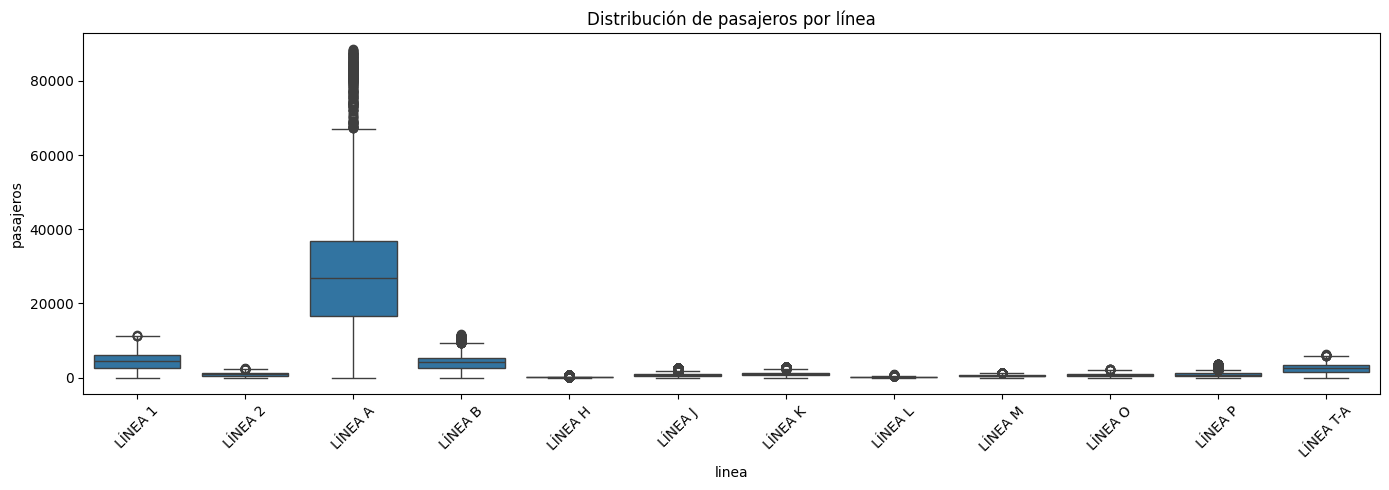

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("DISTRIBUCIÓN DE NULOS\n")

print("Por línea:")
print(df_long[df_long["pasajeros"].isna()].groupby("linea").size().sort_values(ascending=False))

print("\nPor hora:")
print(df_long[df_long["pasajeros"].isna()].groupby("hora").size().sort_values(ascending=False))

print("\nPor día de semana:")
print(df_long[df_long["pasajeros"].isna()].groupby("dia_semana").size().sort_values(ascending=False))

df_long["pasajeros"] = pd.to_numeric(df_long["pasajeros"], errors="coerce")

print("\nESTADÍSTICAS GENERALES DE PASAJEROS")
print(df_long["pasajeros"].describe())
print(f"Skewness: {df_long['pasajeros'].skew():.3f}")

# Distribución por línea (boxplot)
plt.figure(figsize=(14, 5))
sns.boxplot(data=df_long, x="linea", y="pasajeros", order=sorted(df_long["linea"].unique()))
plt.title("Distribución de pasajeros por línea")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Dado que la distribución de pasajeros presenta un sesgo positivo alto, con valores extremos que alcanzan los 88.553 pasajeros y una brecha significativa entre la media (4.193) y la mediana (987), se optó por imputar los valores faltantes con la mediana. A diferencia de la media, la mediana es robusta frente a outliers y representa mejor el valor típico en distribuciones asimétricas. Adicionalmente, la imputación se realizó de forma segmentada por línea, hora y día de la semana, ya que la afluencia varía estructuralmente según estos factores. Este enfoque garantiza que cada valor imputado sea coherente con el contexto operativo real del registro.

In [103]:
df_long["pasajeros"] = df_long.groupby(
    ["linea", "hora", "dia_semana"]
)["pasajeros"].transform(
    lambda x: x.fillna(x.median())
)

print(f"Nulos restantes: {df_long['pasajeros'].isna().sum()}")

c:\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Nulos restantes: 48


Con esta primera imputación por linea, hora y día de la semana, quedan 48 nulos que no tiene valores correspondientes a esta agrupación, por lo tanto haremos una segunda mas reducida

In [104]:
df_long["pasajeros"] = df_long.groupby(
    ["linea", "hora"]
)["pasajeros"].transform(
    lambda x: x.fillna(x.median())
)

print(f"Nulos restantes: {df_long['pasajeros'].isna().sum()}")

Nulos restantes: 0


In [105]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80655 entries, 0 to 80654
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       80655 non-null  datetime64[ns]
 1   linea       80655 non-null  object        
 2   semana      80655 non-null  int32         
 3   dia_semana  80655 non-null  int32         
 4   festivo     80655 non-null  int64         
 5   hora        80655 non-null  object        
 6   pasajeros   80655 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int32(2), int64(1), object(2)
memory usage: 3.7+ MB


6. Ahora vamos a codificar las variables, como notamos las variables dia_semana, semana, festivo ya estan numericos y en rangos pequeños, por lo tanto vamos a decidir dejarlos así y no normalizar su escala. Para las variables hora y linea que son categoricas se aplicaron dos estrategias distintas según la naturaleza de cada variable. La variable hora se trató con Label Encoding (conversión directa a entero), ya que representa una variable ordinal con un orden cronológico natural — las horas tienen una progresión lógica que los modelos pueden aprovechar directamente. Por su parte, la variable linea se codificó con One-Hot Encoding, ya que es una variable nominal donde no existe ningún orden inherente entre las líneas del metro, por lo que asignarle valores enteros introduciría una jerarquía artificial que podría sesgar el modelo.

In [106]:
#Hora
df_long["hora"] = df_long["hora"].astype(int)

#Linea
dummies = pd.get_dummies(df_long["linea"], prefix="linea")
df_long = pd.concat([df_long, dummies], axis=1)

# Verificación
print(df_long.shape)
print(df_long.dtypes)
print(df_long.head())

(80655, 19)
fecha              datetime64[ns]
linea                      object
semana                      int32
dia_semana                  int32
festivo                     int64
hora                        int32
pasajeros                 float64
linea_LÍNEA 1                bool
linea_LÍNEA 2                bool
linea_LÍNEA A                bool
linea_LÍNEA B                bool
linea_LÍNEA H                bool
linea_LÍNEA J                bool
linea_LÍNEA K                bool
linea_LÍNEA L                bool
linea_LÍNEA M                bool
linea_LÍNEA O                bool
linea_LÍNEA P                bool
linea_LÍNEA T-A              bool
dtype: object
       fecha    linea  semana  dia_semana  festivo  hora  pasajeros  \
0 2024-01-01  LÍNEA 1       1           0        1     4      180.0   
1 2024-01-01  LÍNEA 2       1           0        1     4        1.0   
2 2024-01-01  LÍNEA A       1           0        1     4     1460.0   
3 2024-01-01  LÍNEA B       1           0   

# Cronología

Debido a que la afluencia de pasajeros corresponde a un fenómeno temporal, las variables originales no eran suficientes para capturar la dependencia entre observaciones consecutivas. Con únicamente variables como semana, día de la semana, hora y línea, el modelo tendería a generar predicciones muy similares para intervalos de tiempo equivalentes, ignorando el comportamiento reciente del sistema.

Para incorporar información temporal al modelo, se agregaron variables históricas calculadas sobre la misma línea del sistema de transporte. Estas variables permiten introducir memoria temporal y capturar patrones de corto y mediano plazo en la demanda de pasajeros.

Las variables históricas seleccionadas fueron:

- La cantidad de pasajeros registrada en la hora inmediatamente anterior.
- El promedio de pasajeros de la misma línea durante el día inmediatamente anterior.
- La cantidad de pasajeros registrada en la misma hora de la semana anterior.

Con estas características el modelo puede considerar no solo el contexto temporal general, sino también el comportamiento reciente y los patrones periódicos de la serie de tiempo.

1. Ordenar el dataset por [linea -> fecha -> hora] para estructurarlo adecuadamente y obtener así los valores previos necesarios para las nuevas columnas

In [108]:
# Ordenar cronológicamente por línea, fecha y hora
df_long = df_long.sort_values(["linea", "fecha", "hora"]).reset_index(drop=True)

2. Generar la columna lag_1 que corresponde a la cantidad de pasajeros en cada linea, en la hora anterior.

In [110]:
# Cantidad de pasajeros en la hora inmediatamente anterior
df_long["lag_1"] = (
    df_long
    .groupby(["linea", "fecha"])["pasajeros"]
    .shift(1)
)

3. Generar la columna promedio_dia_anterior que corresponde al promedio por hora, del día anterior, para cada linea. Cabe aclarar que este valor se repetirá en todas las muestras de las diferentes horas para la misma línea en el mismo día.

In [124]:
#Auxiliar para guardar el total de pasajeros y las horas de operación de una linea en un día
resumen_diario = (
    df_long
    .groupby(["linea", "fecha"])
    .agg(
        total_pasajeros=("pasajeros", "sum"),
        horas_operacion=("pasajeros", "count")
    )
    .reset_index()
)

#Calcular el promedio
resumen_diario["promedio_dia"] = (
    resumen_diario["total_pasajeros"] /
    resumen_diario["horas_operacion"]
).round().astype(int)

#Agregar una columna para el día anterior a cada línea
resumen_diario["promedio_dia_anterior"] = (
    resumen_diario
    .groupby("linea")["promedio_dia"]
    .shift(1)
)

#Concatenar a df_long
df_long = df_long.merge(
    resumen_diario[["linea", "fecha", "promedio_dia_anterior"]],
    on=["linea", "fecha"],
    how="left"
)

In [127]:
df_long[513:517]

,fecha,linea,semana,dia_semana,festivo,hora,pasajeros,linea_LÍNEA 1,linea_LÍNEA 2,linea_LÍNEA A,...,linea_LÍNEA H,linea_LÍNEA J,linea_LÍNEA K,linea_LÍNEA L,linea_LÍNEA M,linea_LÍNEA O,linea_LÍNEA P,linea_LÍNEA T-A,lag_1,promedio_dia_anterior
513,2024-01-27,LÍNEA 1,4,5,0,22,1190.0,True,False,False,...,False,False,False,False,False,False,False,False,2106.0,5319.0
514,2024-01-27,LÍNEA 1,4,5,0,23,72.0,True,False,False,...,False,False,False,False,False,False,False,False,1190.0,5319.0
515,2024-01-28,LÍNEA 1,4,6,0,4,513.0,True,False,False,...,False,False,False,False,False,False,False,False,NaN,3990.0
516,2024-01-28,LÍNEA 1,4,6,0,5,1623.0,True,False,False,...,False,False,False,False,False,False,False,False,513.0,3990.0


3. Crear la columna misma_hora_semana_anterior que, como su nombre lo dice, corresponde a la cantidad de usuarios registrados en cada linea, a la misma hora que se desea predecir, para la semana anterior.

In [128]:
#Crear tabla histórica
historico_semana = df_long[
    ["linea", "semana", "dia_semana", "hora", "pasajeros"]
].copy()

#Crear la columna
historico_semana = historico_semana.rename(
    columns={"pasajeros": "misma_hora_semana_anterior"}
)

#Aumentar en 1 el valor de semana, para posteriormente hacer un merge
historico_semana["semana"] += 1

#Merge
df_long = df_long.merge(
    historico_semana,
    on=["linea", "semana", "dia_semana", "hora"],
    how="left"
)

In [131]:
#Comprobar

linea = "LÍNEA A"
hora = 18
fecha = "2024-03-04"

# Registro original
original = df_long[
    (df_long["linea"] == linea) &
    (df_long["hora"] == hora) &
    (df_long["fecha"] == fecha)
]

# Registro una semana después
siguiente = df_long[
    (df_long["linea"] == linea) &
    (df_long["hora"] == hora) &
    (df_long["fecha"] == "2024-03-11")
]

print("ORIGINAL")
print(original[["fecha", "semana", "linea", "hora", "pasajeros"]])

print("\nSEMANA SIGUIENTE")
print(siguiente[[
    "fecha",
    "semana",
    "linea",
    "hora",
    "misma_hora_semana_anterior"
]])

ORIGINAL
           fecha  semana    linea  hora  pasajeros
15827 2024-03-04      10  LÍNEA A    18    55857.0

SEMANA SIGUIENTE
           fecha  semana    linea  hora  misma_hora_semana_anterior
15966 2024-03-11      11  LÍNEA A    18                     55857.0


In [132]:
# Guardar como CSV
df_long.to_csv('./afluencia_metro_2024_transformado.csv', index=False)


In [ ]:
df_long